<a href="https://colab.research.google.com/github/di-claro-batera/faculdade_data_science/blob/main/Exemplo_de_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

from google.colab import files
uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Mounted at /content/drive


Saving test_signs.h5 to test_signs.h5
Saving train_signs.h5 to train_signs.h5
User uploaded file "test_signs.h5" with length 1477712 bytes
User uploaded file "train_signs.h5" with length 13281872 bytes


# Importando as Bibliotecas

In [9]:
import keras
import math
import numpy as np
import h5py
import matplotlib.pyplot as plt
import scipy
from PIL import Image
from scipy import ndimage
import tensorflow as tf
from tensorflow.python.framework import ops
from tensorflow.keras import datasets, layers, models

keras.backend.clear_session()


In [10]:
# conversao para one_hot
def convert_to_one_hot(Y, C):
  Y = np.eye(C)[Y.reshape(-1)].T
  return Y

# extraindo os conjuntos
def load_dataset():
  train_dataset = h5py.File('train_signs.h5', "r")
  train_set_x_orig = np.array(train_dataset["train_set_x"][:])
  train_set_y_orig = np.array(train_dataset["train_set_y"][:])

  test_dataset = h5py.File('test_signs.h5', "r")
  test_set_x_orig = np.array(test_dataset["test_set_x"][:])
  test_set_y_orig = np.array(test_dataset["test_set_y"][:])

  classes = np.array(test_dataset["list_classes"][:])

  train_set_y_orig = train_set_y_orig.reshape((1, train_set_y_orig.shape[0]))
  test_set_y_orig = test_set_y_orig.reshape((1, test_set_y_orig.shape[0]))

  return train_set_x_orig, train_set_y_orig, test_set_x_orig, test_set_y_orig, classes

# carregando os exemplos
train_images, train_labels, test_images, test_labels, classes = load_dataset()

y = 5


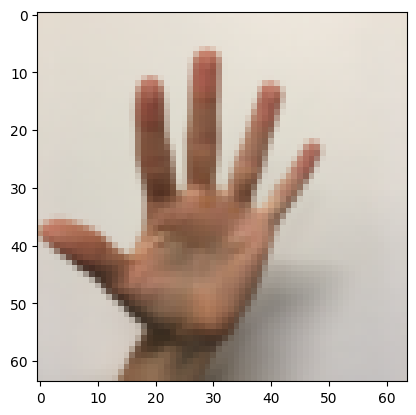

In [11]:
# Exemplo de uma figura
index = 3
plt.imshow(train_images[index])
print("y = " + str(np.squeeze(train_labels[:, index])))

In [12]:
train_images = train_images/255 # normalização para range de 0 a 1, RGB é de 0 a 255
test_images = test_images/255 # normalização para range de 0 a 1 RGB é de 0 a 255
train_labels = convert_to_one_hot(train_labels, 6).T # one_hot
test_labels = convert_to_one_hot(test_labels, 6).T # one_hot
train_labels = np.argmax(train_labels, axis=1)
test_labels = np.argmax(test_labels, axis=1)

# verificando as dimensões
print("number of training examples = " + str(train_images.shape[0]))
print("number of test examples = " + str(test_images.shape[0]))
print("train_images shape: " + str(train_images.shape))
print("train_labels shape: " + str(train_labels.shape))
print("test_images shape: " + str(test_images.shape))
print("test_labels shape: " + str(test_labels.shape))

number of training examples = 1080
number of test examples = 120
train_images shape: (1080, 64, 64, 3)
train_labels shape: (1080,)
test_images shape: (120, 64, 64, 3)
test_labels shape: (120,)


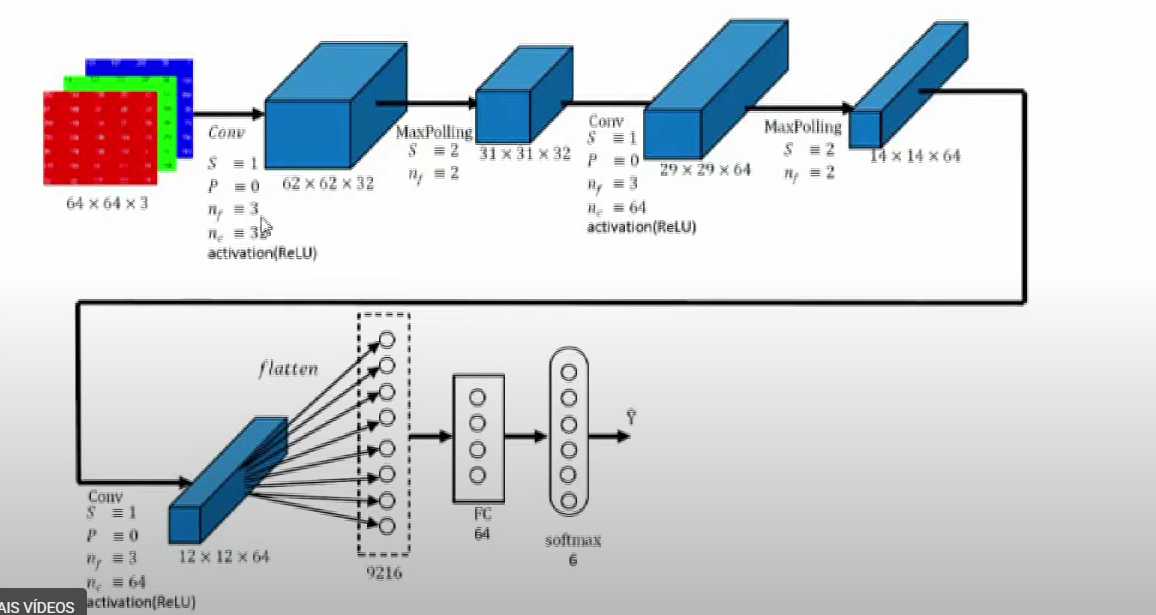

In [13]:
model = models.Sequential()
model.add(layers.Conv2D(filters=32, kernel_size=(3, 3), strides=(1, 1), padding='valid', activation='relu', input_shape=(64, 64, 3)))
model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid'))
model.add(layers.Conv2D(filters=64, kernel_size=(3, 3), strides=(1, 1), padding='valid', activation='relu'))
model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2), padding='valid'))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(6, activation='softmax'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       589,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 646,598 (2.47 MB)

 Trainable params: 646,598 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

# Treinamento e Validação

In [15]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model.fit(train_images, train_labels, epochs=10, batch_size=None,
                    validation_data=(test_images, test_labels))

Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 240ms/step - accuracy: 0.1812 - loss: 1.8876 - val_accuracy: 0.3083 - val_loss: 1.7309
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 9s 194ms/step - accuracy: 0.3763 - loss: 1.6177 - val_accuracy: 0.5417 - val_loss: 1.1722
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 216ms/step - accuracy: 0.5782 - loss: 1.1313 - val_accuracy: 0.7333 - val_loss: 0.9477
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 8s 236ms/step - accuracy: 0.7190 - loss: 0.8504 - val_accuracy: 0.7083 - val_loss: 0.8310
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 8s 179ms/step - accuracy: 0.7879 - loss: 0.6522 - val_accuracy: 0.7667 - val_loss: 0.6383
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 11s 206ms/step - accuracy: 0.8274 - loss: 0.5172 - val_accuracy: 0.7833 - val_loss: 0.5577
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 8s 250ms/step - accuracy: 0.8407 - loss: 0.4541 - val_accuracy: 0.8417 - val_loss: 0.4454
Epoch 8/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 184ms/step - accuracy: 0.8939 - loss: 0.3408 - val_accuracy: 

# Gerando o gráfico de Acurácia para o conjunto de treinamento e validação

4/4 - 0s - 104ms/step - accuracy: 0.8667 - loss: 0.3430


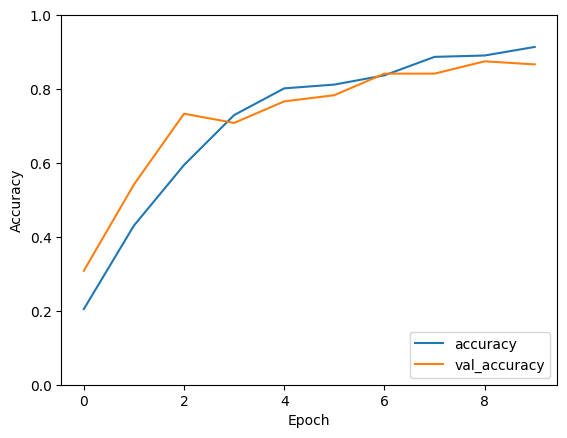

In [16]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.0, 1])
plt.legend(loc='lower right')
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)

# Gerando o gráfico da função de Custo

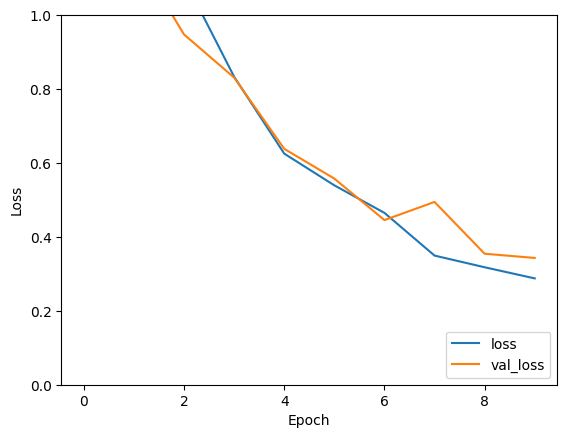

In [17]:
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim([0.0, 1])
plt.legend(loc='lower right')

# Testando para uma imagem qualquer

In [18]:
from google.colab import files

uploaded=  files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Saving 20062012maosFotoMarcosSantos020.jpg to 20062012maosFotoMarcosSantos020.jpg
User uploaded file "20062012maosFotoMarcosSantos020.jpg" with length 338872 bytes


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
[[0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]]


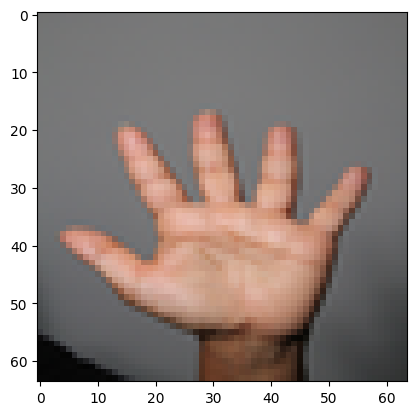

In [21]:
from PIL import Image

basewidth = 300
img= Image.open('20062012maosFotoMarcosSantos020.jpg')
img= img.resize((64, 64), Image.Resampling.LANCZOS)
resized= np.array(img)
plt.imshow(resized)
resized= np.expand_dims(resized, axis=0)

predictions = model.predict(resized)
print((predictions.T))